In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

# Encontrar el logotipo de la gaseosa dentro de la carpeta imagenes

[X] logo_1.png , NO detectado (medida=0.29)


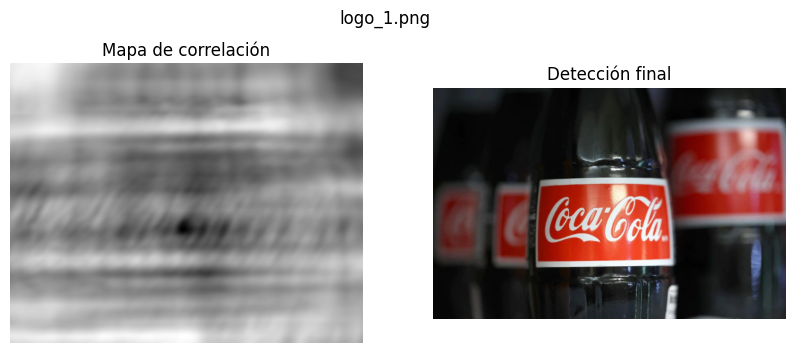

[X] coca_retro_2.png , NO detectado (medida=0.33)


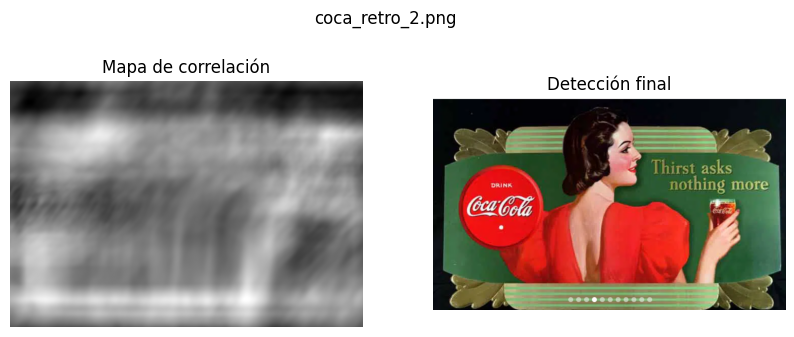

[X] coca_multi.png , NO detectado (medida=0.39)


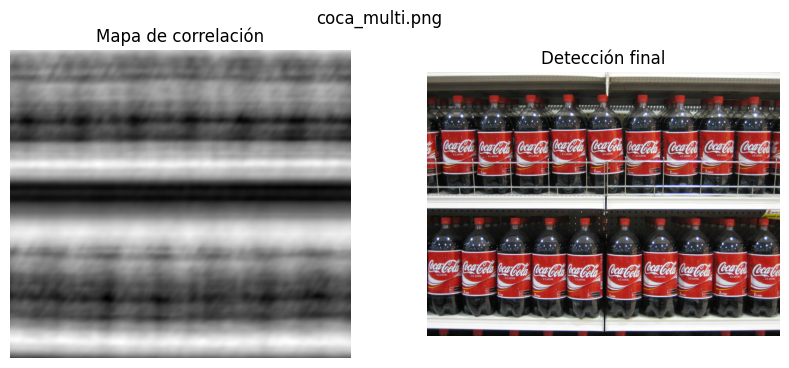

[X] coca_retro_1.png , NO detectado (medida=0.60)


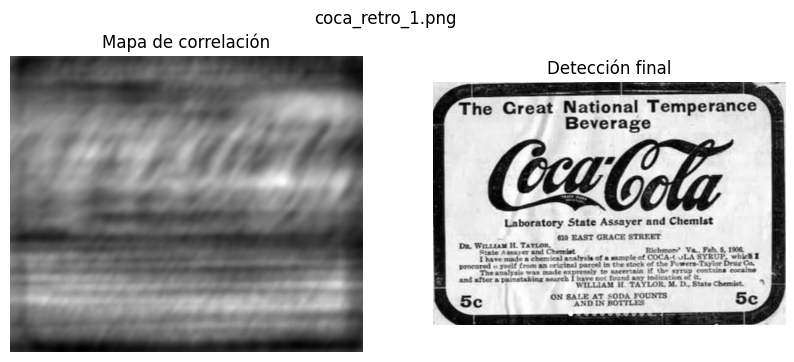

[X] COCA-COLA-LOGO.jpg , NO detectado (medida=0.33)


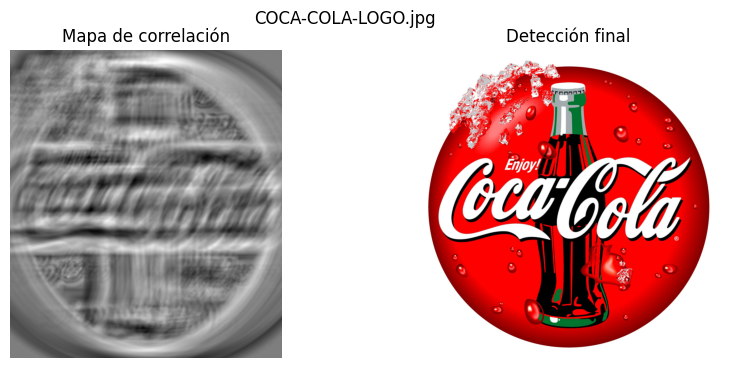

[X] coca_logo_1.png , NO detectado (medida=0.00)


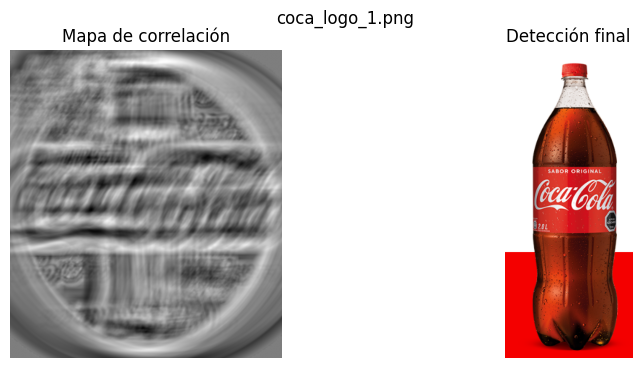

[X] coca_logo_2.png , NO detectado (medida=0.00)


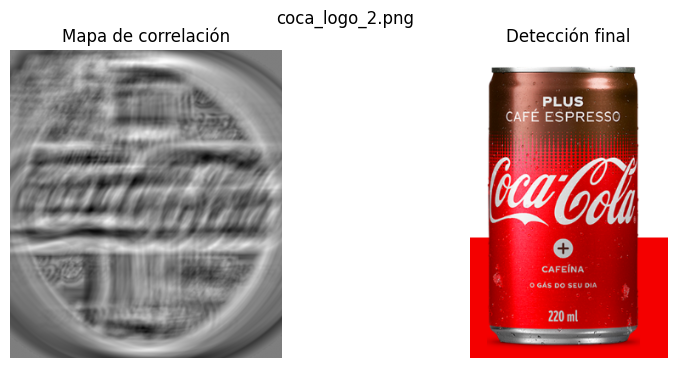

In [18]:
images_path = "images"
template_path = "template/pattern.png"

template = cv.imread(template_path, 0)
template = cv.GaussianBlur(template, (3,3), 0)

w, h = template.shape[::-1]

method = cv.TM_CCOEFF_NORMED

#umbral alto, evita falsos positivos
threshold = 0.85

#recorrer imágenes
for filename in os.listdir(images_path):

    img_path = os.path.join(images_path, filename)
    img = cv.imread(img_path)

    if img is None:
        continue

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_gray = cv.GaussianBlur(img_gray, (3,3), 0)

    best_val = 0
    best_loc = None
    best_scale = 1
    
    # MULTI ESCALA
    scales = np.linspace(0.5, 1.5, 10)

    for scale in scales:
        resized = cv.resize(img_gray, None, fx=scale, fy=scale)

        if resized.shape[0] < h or resized.shape[1] < w:
            continue

        res = cv.matchTemplate(resized, template, method)
        _, max_val, _, max_loc = cv.minMaxLoc(res)

        if max_val > best_val:
            best_val = max_val
            best_loc = max_loc
            best_scale = scale

    # detección final
    if best_val >= threshold:

        top_left = (int(best_loc[0] / best_scale),
                    int(best_loc[1] / best_scale))

        bottom_right = (int((best_loc[0] + w) / best_scale),
                        int((best_loc[1] + h) / best_scale))

        cv.rectangle(img_rgb, top_left, bottom_right, (0,255,0), 3)

        print(f"[OK] {filename} , mejor medida={best_val:.2f}")

    else:
        print(f"[X] {filename} , NO detectado (medida={best_val:.2f})")

    # visualización
    plt.figure(figsize=(10,4))

    plt.subplot(121)
    plt.imshow(res, cmap='gray')
    plt.title("Mapa de correlación")
    plt.axis("off")

    plt.subplot(122)
    plt.imshow(img_rgb)
    plt.title("Detección final")
    plt.axis("off")

    plt.suptitle(filename)
    plt.show()

# Análisis de la implementación de la parte 1

## Detección de logotipo mediante Template Matching

Para resolver la detección del logotipo en las imágenes provistas para este TP, se implementó un enfoque basado en template matching, la cual permite localizar un template (pattern.png) dentro de una imagen más grande.
Antes de aplicar el algoritmo, tanto la imagen como el template se convierten a escala de grises y se les aplica un suavizado Gaussiano el cual reduce ruido, evita falsas detecciones por variaciones pequeñas y mejora la probabilidad del matching.
Dentro de los metodos para aplicar template matching se seleccionó el cv.TM_CCOEFF_NORMED, el cual calcula la correlación normalizada entre la imagen y el template siendo invariante a los cambios en la iluminación de la imagen.
Para el umbral de decisión se tomo el valor de 0.85 por convención siendo este un umbral significativo para reducir los falsos positivos requisito del TP.
También se consideró un enfoque multi escala, debido a que el tamaño del logotipo puede variar entre las escalas de las imagenes proporcionadas, esto se debe por ejemplo a distintas resoluciones de la camara o distancia en la cual se encontraba la camara.
Para selecionar la mejor coincidencia encontrada se mantiene el maximo valor por imagen ( valor de similitud (max_val)), conservando el mejor puntaje.
El enfoque implementado permite detectar el logotipo evitando falsos positivos mediante, uso de correlación normalizada, umbral alto de decisión, búsqueda multi-escala.




# Parte 2 - Algoritmo para multiples detecciones

nivel 0 , max score: 0.357
nivel 1 , max score: 0.196


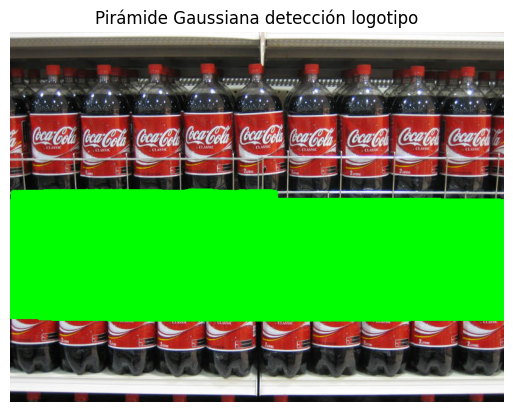

In [35]:

img_color = cv.imread("images/coca_multi.png")
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)

template = cv.imread("template/pattern.png", 0)
template = cv.GaussianBlur(template, (5,5), 0)

method = cv.TM_CCOEFF_NORMED
threshold = 0.3
levels = 5

boxes = []
current_img = img_gray.copy()

for level in range(levels):

    if current_img.shape[0] < template.shape[0] or current_img.shape[1] < template.shape[1]:
        break

    scale = 1 / (2 ** level)

    current_blur = cv.GaussianBlur(current_img, (5,5), 0)

    res = cv.matchTemplate(current_blur, template, method)

    print(f"nivel {level} , max score: {res.max():.3f}")

    loc = np.where(res >= threshold)

    h, w = template.shape[:2]

    for pt in zip(*loc[::-1]):
        x, y = pt
        score = res[y, x]

        x_orig = int(x / scale)
        y_orig = int(y / scale)
        w_orig = int(w / scale)
        h_orig = int(h / scale)

        boxes.append([x_orig, y_orig, w_orig, h_orig, score])

    current_img = cv.pyrDown(current_img) # se crea la piramide gaussiana

for (x, y, w, h, score) in boxes:
     cv.rectangle(img_rgb, (x, y), (x+w, y+h), (0,255,0), 2)    
     text = f"{score:.2f}"
     cv.putText(img_rgb, text, (x, y-5),cv.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1,cv.LINE_AA)

plt.imshow(img_rgb)
plt.title("Pirámide Gaussiana detección logotipo")
plt.axis("off")
plt.show()

# Análisis para la detección de múltiple

Para la realización de este experimento se decidió aplicar piramide gaussiana, ya que el problema se reduce a detectar en una imagen con multiples logotipos, si el template se detecta en la imagen coca_multi.
Se implementó una pirámide gaussiana mediante la función pyrDown, la cual reduce progresivamente la resolución de la imagen aplicando un suavizado previo basado en un filtro gaussiano. Esto permite detectar el objeto a distintas escalas sin modificar el template. En cada nivel de la pirámide se realizó template matching, y las detecciones obtenidas fueron reescaladas a las dimensiones originales de la imagen.

Para determinar las coincidencias se utilizó un umbral (threshold) de 0.3 sobre la métrica de correlación normalizada (TM_CCOEFF_NORMED). Se experimentó con valores más altos, como 0.5, pero no se obtuvieron detecciones. Esto se debe a que los valores máximos de correlación observados fueron relativamente bajos (inferiores a 0.4), lo cual indica que el template no coincide de forma exacta con las instancias presentes en la imagen.
Las detecciones obtenidas se representan mediante rectángulos verdes superpuestos sobre la imagen original.



## Adecuar el algoritmo para detectar en todas las imagenes dadas

In [34]:
output_folder = "resultados/"
os.makedirs(output_folder, exist_ok=True)

template = cv.imread("template/pattern.png", 0)
template = cv.GaussianBlur(template, (5,5), 0)

method = cv.TM_CCOEFF_NORMED
threshold = 0.3
levels = 5

# loop sobre las imagenes dentro del directorio
for filename in os.listdir("images/"):
    if not filename.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    print(f"\nProcesando: {filename}")

    path = os.path.join("images/", filename)

    img_color = cv.imread(path)
    img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
    img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)

    boxes = []
    current_img = img_gray.copy()

    for level in range(levels):

        if current_img.shape[0] < template.shape[0] or current_img.shape[1] < template.shape[1]:
            break

        scale = 1 / (2 ** level)
        current_blur = cv.GaussianBlur(current_img, (5,5), 0)
        res = cv.matchTemplate(current_blur, template, method)
        print(f"nivel {level} → max score: {res.max():.3f}")
        loc = np.where(res >= threshold)

        h, w = template.shape[:2]

        for pt in zip(*loc[::-1]):
            x, y = pt
            score = res[y, x]

            x_orig = int(x / scale)
            y_orig = int(y / scale)
            w_orig = int(w / scale)
            h_orig = int(h / scale)

            boxes.append([x_orig, y_orig, w_orig, h_orig, score])

        current_img = cv.pyrDown(current_img)

    for (x, y, w, h, score) in boxes:
        # rectángulo
        cv.rectangle(img_rgb, (x, y), (x+w, y+h), (0,255,0), 2)  
        # texto (confianza)
        text = f"{score:.2f}"
        
        cv.putText(img_rgb, text, (x, y-5),cv.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),1,cv.LINE_AA)

    # Almaceno el resultado 
    output_path = os.path.join(output_folder, f"det_{filename}")
    plt.imsave(output_path, img_rgb)

    print(f"Detecciones: {len(boxes)}")


Procesando: logo_1.png
nivel 0 → max score: 0.161
Detecciones: 0

Procesando: coca_retro_2.png
nivel 0 → max score: 0.304
Detecciones: 21

Procesando: coca_multi.png
nivel 0 → max score: 0.357
nivel 1 → max score: 0.196
Detecciones: 7333

Procesando: coca_retro_1.png
nivel 0 → max score: 0.289
Detecciones: 0

Procesando: COCA-COLA-LOGO.jpg
nivel 0 → max score: 0.305
nivel 1 → max score: 0.250
Detecciones: 80

Procesando: coca_logo_1.png
Detecciones: 0

Procesando: coca_logo_2.png
Detecciones: 0


# Conclusiones 

El algoritmo implementado logra detectar algunas instancias del objeto, pero con precisión limitada. La baja similitud entre el template y las instancias reales obliga a utilizar umbrales bajos, lo que incrementa la cantidad de detecciones incorrectas.
